# PS-001 Workforce Data Foundation — Exploratory Analysis

This notebook validates the canonical workforce parquet, profiles the core distributions, generates static report figures, and exports the summary artefacts required for downstream narrative compilation.

Business question: do we have a single trusted, auditable dataset of historical healthcare workforce headcount that is ready for trend analysis and forecasting?

In [4]:
from __future__ import annotations

from datetime import datetime
from pathlib import Path
import json

from loguru import logger
import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns
import yaml

CANDIDATE_ROOTS = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
ROOT = next(path for path in CANDIDATE_ROOTS if (path / "shared").exists() and (path / "docs").exists())
DATA_PATH = ROOT / "shared/data/4_processed/workforce_clean.parquet"
ARTEFACT_ROOT = ROOT / "artifacts/ps-001-workforce-data-foundation"
FIGURES_DIR = ARTEFACT_ROOT / "reports/figures"
TABLES_DIR = ARTEFACT_ROOT / "results/tables"
HANDOFF_DIR = ROOT / "docs/agent-handoffs/exploratory-analysis/ps-001-workforce-data-foundation"
LOG_DIR = ARTEFACT_ROOT / "logs/analysis"
LOG_PATH = LOG_DIR / f"exploratory_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"
SUMMARY_STATS_PATH = TABLES_DIR / "eda_summary_stats.csv"
FINDINGS_PATH = TABLES_DIR / "eda_findings.yml"
HANDOFF_PATH = HANDOFF_DIR / "eda_to_narrative_20260423.json"
PROFESSION_FIGURE_PATH = FIGURES_DIR / "headcount_by_profession_year.png"
SECTOR_FIGURE_PATH = FIGURES_DIR / "headcount_by_sector_year.png"

for path in [FIGURES_DIR, TABLES_DIR, HANDOFF_DIR, LOG_DIR]:
    path.mkdir(parents=True, exist_ok=True)

logger.remove()
logger.add(LOG_PATH, level="INFO")
logger.add(lambda message: print(message, end=""), level="INFO")

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 150

EXPECTED_COLUMNS = {"year", "sector", "count", "profession"}
logger.info(f"Configured paths and logger for exploratory analysis under root {ROOT}.\n")

2026-04-23 07:03:06.625 | INFO     | __main__:<module>:40 - Configured paths and logger for exploratory analysis under root /Users/alfredtang/Documents/Projects/gen-e2/gen-e2-data-analysis.



## Load Data And Inspect Schema

The canonical parquet is the shared contract produced by the cleaning stage. This section checks that the schema matches the PS-001 data contract before any aggregation is performed.

In [5]:
df = pl.read_parquet(DATA_PATH)
logger.info(f"Loaded workforce parquet from {DATA_PATH} with shape {df.shape}.\n")

assert set(df.columns) == EXPECTED_COLUMNS, f"Unexpected columns: {df.columns}"

print("Shape:", df.shape)
print("Schema:", df.schema)
print("Dtypes:", df.dtypes)
df.head(10)

2026-04-23 07:03:11.074 | INFO     | __main__:<module>:2 - Loaded workforce parquet from /Users/alfredtang/Documents/Projects/gen-e2/gen-e2-data-analysis/shared/data/4_processed/workforce_clean.parquet with shape (264, 4).

Shape: (264, 4)
Schema: Schema([('year', Int32), ('sector', Categorical), ('count', Int32), ('profession', Categorical)])
Dtypes: [Int32, Categorical, Int32, Categorical]


year,sector,count,profession
i32,cat,i32,cat
2006,"""Public""",3505,"""doctors"""
2006,"""Private""",2966,"""doctors"""
2006,"""Not In Active Practice""",460,"""doctors"""
2007,"""Public""",3991,"""doctors"""
2007,"""Private""",3004,"""doctors"""
2007,"""Not In Active Practice""",469,"""doctors"""
2008,"""Public""",1723,"""doctors"""
2008,"""Public""",2574,"""doctors"""
2008,"""Private""",1046,"""doctors"""


## Univariate Analysis

This section describes the distribution of workforce counts by profession, confirms year coverage across professions, and checks the sector mix in the cleaned dataset.

In [6]:
profession_stats = (
    df.group_by("profession")
    .agg(
        pl.col("count").min().alias("count_min"),
        pl.col("count").max().alias("count_max"),
        pl.col("count").mean().round(2).alias("count_mean"),
        pl.col("count").median().alias("count_median"),
        pl.col("count").std().round(2).alias("count_std"),
        pl.col("count").sum().alias("count_total"),
        pl.len().alias("row_count"),
    )
    .sort("profession")
)

year_coverage = (
    df.group_by("profession")
    .agg(
        pl.col("year").min().alias("year_min"),
        pl.col("year").max().alias("year_max"),
        pl.col("year").n_unique().alias("year_n_unique"),
    )
    .sort("profession")
)

sector_distribution = (
    df.group_by("sector")
    .agg(
        pl.len().alias("rows"),
        pl.col("count").sum().alias("total_count"),
    )
    .with_columns(
        (pl.col("rows") / pl.col("rows").sum() * 100).round(2).alias("row_share_pct"),
        (pl.col("total_count") / pl.col("total_count").sum() * 100).round(2).alias("headcount_share_pct"),
    )
    .sort("total_count", descending=True)
)

print("Count distribution by profession")
display(profession_stats)
print("\nYear coverage by profession")
display(year_coverage)
print("\nSector distribution")
display(sector_distribution)

logger.info("Computed univariate profession, year coverage, and sector distribution tables.\n")

Count distribution by profession


profession,count_min,count_max,count_mean,count_median,count_std,count_total,row_count
cat,i32,i32,f64,f64,f64,i32,u32
"""doctors""",193,5166,1910.29,1789.0,1467.7,149003,78
"""nurses""",29,21373,3725.85,2038.0,4949.84,469457,126
"""pharmacists""",133,1616,770.21,850.0,482.16,32349,42
"""physiotherapists""",2,960,579.83,723.5,346.6,10437,18



Year coverage by profession


profession,year_min,year_max,year_n_unique
cat,i32,i32,u32
"""doctors""",2006,2019,14
"""nurses""",2006,2019,14
"""pharmacists""",2006,2019,14
"""physiotherapists""",2014,2019,6



Sector distribution


sector,rows,total_count,row_share_pct,headcount_share_pct
cat,u32,i32,f64,f64
"""Public""",88,391043,33.33,59.14
"""Private""",88,187903,33.33,28.42
"""Not In Active Practice""",88,82300,33.33,12.45


2026-04-23 07:03:17.744 | INFO     | __main__:<module>:45 - Computed univariate profession, year coverage, and sector distribution tables.



The profession distributions show the scale differences that matter most for downstream trend analysis. Year coverage should be complete across all professions from the first to the last year in the dataset, and the sector distribution indicates where the bulk of headcount sits before time-based comparisons.

## Bivariate Analysis And Figure Export

The two core report figures aggregate headcount across time by profession and by sector. These are the main trend views required for the narrative handoff.

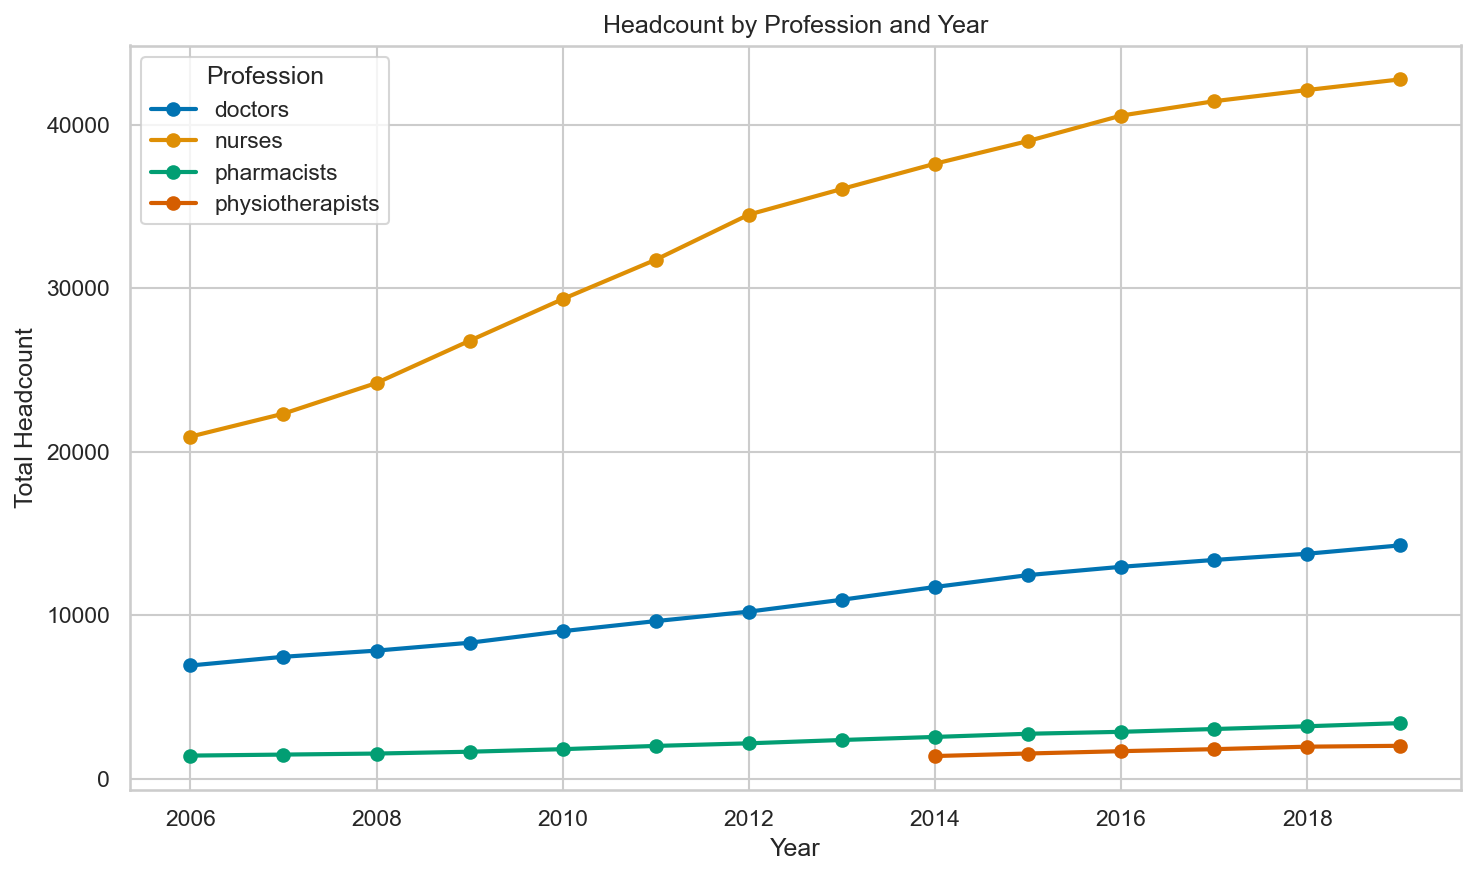

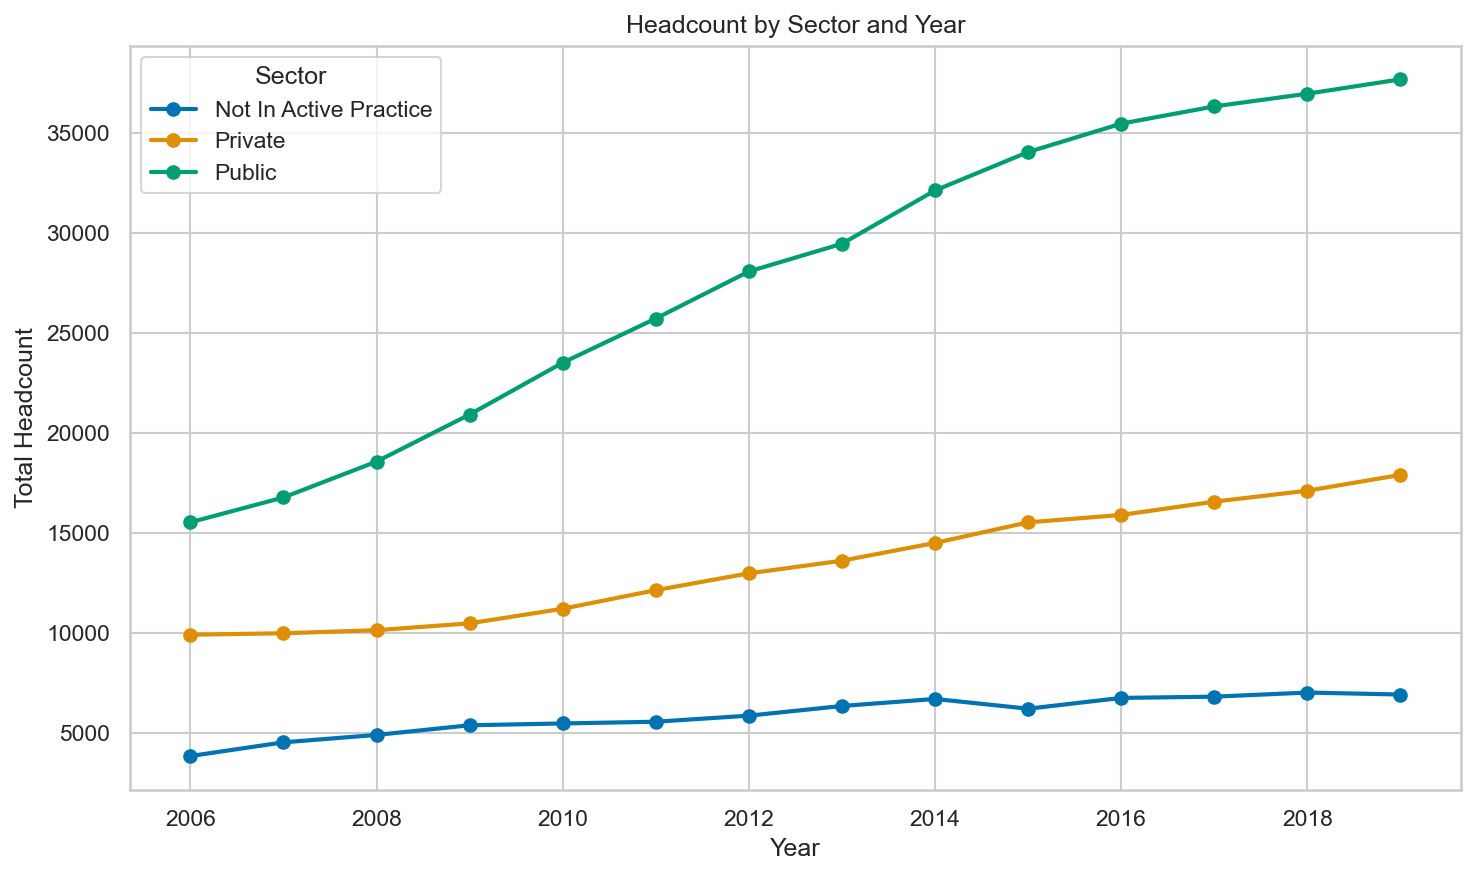

Saved /Users/alfredtang/Documents/Projects/gen-e2/gen-e2-data-analysis/artifacts/ps-001-workforce-data-foundation/reports/figures/headcount_by_profession_year.png
Saved /Users/alfredtang/Documents/Projects/gen-e2/gen-e2-data-analysis/artifacts/ps-001-workforce-data-foundation/reports/figures/headcount_by_sector_year.png
2026-04-23 07:03:21.930 | INFO     | __main__:<module>:53 - Exported profession and sector headcount figures.



In [7]:
profession_year = (
    df.group_by(["profession", "year"])
    .agg(pl.col("count").sum().alias("total_count"))
    .sort(["profession", "year"])
)

sector_year = (
    df.group_by(["sector", "year"])
    .agg(pl.col("count").sum().alias("total_count"))
    .sort(["sector", "year"])
)

fig, ax = plt.subplots(figsize=(10, 6))
for profession in profession_year.get_column("profession").unique().sort().to_list():
    subset = profession_year.filter(pl.col("profession") == profession)
    ax.plot(
        subset.get_column("year").to_list(),
        subset.get_column("total_count").to_list(),
        marker="o",
        linewidth=2,
        label=profession,
    )
ax.set_title("Headcount by Profession and Year")
ax.set_xlabel("Year")
ax.set_ylabel("Total Headcount")
ax.legend(title="Profession")
fig.tight_layout()
fig.savefig(PROFESSION_FIGURE_PATH, bbox_inches="tight")
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(10, 6))
for sector in sector_year.get_column("sector").unique().sort().to_list():
    subset = sector_year.filter(pl.col("sector") == sector)
    ax.plot(
        subset.get_column("year").to_list(),
        subset.get_column("total_count").to_list(),
        marker="o",
        linewidth=2,
        label=sector,
    )
ax.set_title("Headcount by Sector and Year")
ax.set_xlabel("Year")
ax.set_ylabel("Total Headcount")
ax.legend(title="Sector")
fig.tight_layout()
fig.savefig(SECTOR_FIGURE_PATH, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved {PROFESSION_FIGURE_PATH}")
print(f"Saved {SECTOR_FIGURE_PATH}")
logger.info("Exported profession and sector headcount figures.\n")

The profession trend chart should make scale differences immediately visible, while the sector trend chart isolates the relative contribution of public, private, and non-active-practice headcount over time. The export step ensures the notebook also produces static artefacts for reports.

## Key Findings Computation

This section converts the grouped tables into the concrete findings needed by the downstream handoff: growth leader, fastest-growing sector, year span, latest-year total workforce, and the profession ranking by headcount.

In [8]:
profession_growth = (
    profession_year.group_by("profession")
    .agg(
        pl.col("year").min().alias("year_start"),
        pl.col("year").max().alias("year_end"),
        pl.col("total_count").first().alias("count_start"),
        pl.col("total_count").last().alias("count_end"),
    )
    .with_columns((pl.col("count_end") - pl.col("count_start")).alias("absolute_growth"))
    .sort("absolute_growth", descending=True)
)

sector_growth = (
    sector_year.group_by("sector")
    .agg(
        pl.col("year").min().alias("year_start"),
        pl.col("year").max().alias("year_end"),
        pl.col("total_count").first().alias("count_start"),
        pl.col("total_count").last().alias("count_end"),
    )
    .with_columns((pl.col("count_end") - pl.col("count_start")).alias("absolute_growth"))
    .sort("absolute_growth", descending=True)
)

latest_year = df.select(pl.col("year").max()).item()
peak_year = (
    df.group_by("year")
    .agg(pl.col("count").sum().alias("total_count"))
    .sort("total_count", descending=True)
    .row(0, named=True)
)

sector_latest_share = (
    sector_year.filter(pl.col("year") == latest_year)
    .with_columns(
        (pl.col("total_count") / pl.col("total_count").sum() * 100).round(2).alias("share_pct")
    )
    .sort("share_pct", descending=True)
)

profession_rank_latest = (
    profession_year.filter(pl.col("year") == latest_year)
    .sort("total_count", descending=True)
    .select("profession")
    .to_series()
    .to_list()
)

findings = {
    "top_growth_profession": profession_growth.row(0, named=True)["profession"],
    "fastest_growing_sector": sector_growth.row(0, named=True)["sector"],
    "year_range": [int(df.select(pl.col("year").min()).item()), int(latest_year)],
    "peak_year": int(peak_year["year"]),
    "total_workforce_latest_year": int(df.filter(pl.col("year") == latest_year).select(pl.col("count").sum()).item()),
    "largest_sector_latest_year": sector_latest_share.row(0, named=True)["sector"],
    "profession_rank_by_headcount": profession_rank_latest,
}

print(json.dumps(findings, indent=2))
logger.info(f"Computed key findings: {findings}.\n")

{
  "top_growth_profession": "nurses",
  "fastest_growing_sector": "Public",
  "year_range": [
    2006,
    2019
  ],
  "peak_year": 2019,
  "total_workforce_latest_year": 62484,
  "largest_sector_latest_year": "Public",
  "profession_rank_by_headcount": [
    "nurses",
    "doctors",
    "pharmacists",
    "physiotherapists"
  ]
}
2026-04-23 07:03:34.786 | INFO     | __main__:<module>:60 - Computed key findings: {'top_growth_profession': 'nurses', 'fastest_growing_sector': 'Public', 'year_range': [2006, 2019], 'peak_year': 2019, 'total_workforce_latest_year': 62484, 'largest_sector_latest_year': 'Public', 'profession_rank_by_headcount': ['nurses', 'doctors', 'pharmacists', 'physiotherapists']}.



The growth calculations use the first and last observed year for each profession and sector, which is the most direct read of change over the PS-001 history window. The latest-year ranking and sector-share view anchor the handoff in the dataset’s most current workforce composition.

## Summary Statistics Table Export

The CSV export keeps one compact profession-level table for downstream reporting and quick QA checks.

In [9]:
summary_stats = (
    df.group_by("profession")
    .agg(
        pl.col("year").min().alias("year_min"),
        pl.col("year").max().alias("year_max"),
        pl.col("count").min().alias("count_min"),
        pl.col("count").max().alias("count_max"),
        pl.col("count").mean().round(2).alias("count_mean"),
        pl.col("count").sum().alias("count_total"),
    )
    .sort("profession")
)
summary_stats.write_csv(SUMMARY_STATS_PATH)

print(summary_stats)
print(f"Saved summary statistics to {SUMMARY_STATS_PATH}")
logger.info(f"Wrote summary statistics CSV to {SUMMARY_STATS_PATH} with {summary_stats.height} rows.\n")

shape: (4, 7)
┌──────────────────┬──────────┬──────────┬───────────┬───────────┬────────────┬─────────────┐
│ profession       ┆ year_min ┆ year_max ┆ count_min ┆ count_max ┆ count_mean ┆ count_total │
│ ---              ┆ ---      ┆ ---      ┆ ---       ┆ ---       ┆ ---        ┆ ---         │
│ cat              ┆ i32      ┆ i32      ┆ i32       ┆ i32       ┆ f64        ┆ i32         │
╞══════════════════╪══════════╪══════════╪═══════════╪═══════════╪════════════╪═════════════╡
│ doctors          ┆ 2006     ┆ 2019     ┆ 193       ┆ 5166      ┆ 1910.29    ┆ 149003      │
│ nurses           ┆ 2006     ┆ 2019     ┆ 29        ┆ 21373     ┆ 3725.85    ┆ 469457      │
│ pharmacists      ┆ 2006     ┆ 2019     ┆ 133       ┆ 1616      ┆ 770.21     ┆ 32349       │
│ physiotherapists ┆ 2014     ┆ 2019     ┆ 2         ┆ 960       ┆ 579.83     ┆ 10437       │
└──────────────────┴──────────┴──────────┴───────────┴───────────┴────────────┴─────────────┘
Saved summary statistics to /Users/alfredtang/

## EDA Findings YAML Export

The findings YAML is the compact machine-readable summary for downstream narrative assembly.

In [10]:
yaml_payload = {
    "top_growth_profession": findings["top_growth_profession"],
    "fastest_growing_sector": findings["fastest_growing_sector"],
    "year_range": findings["year_range"],
    "total_workforce_latest_year": findings["total_workforce_latest_year"],
    "profession_rank_by_headcount": findings["profession_rank_by_headcount"],
}
FINDINGS_PATH.write_text(yaml.safe_dump(yaml_payload, sort_keys=False), encoding="utf-8")

print(FINDINGS_PATH.read_text(encoding="utf-8"))
logger.info(f"Wrote findings YAML to {FINDINGS_PATH}.\n")

top_growth_profession: nurses
fastest_growing_sector: Public
year_range:
- 2006
- 2019
total_workforce_latest_year: 62484
profession_rank_by_headcount:
- nurses
- doctors
- pharmacists
- physiotherapists

2026-04-23 07:03:52.093 | INFO     | __main__:<module>:11 - Wrote findings YAML to /Users/alfredtang/Documents/Projects/gen-e2/gen-e2-data-analysis/artifacts/ps-001-workforce-data-foundation/results/tables/eda_findings.yml.



## Handoff JSON Export

The final JSON points the next agent to the notebook and exported artefacts, with the key findings embedded from the actual aggregates.

In [11]:
handoff = {
    "agent": "exploratory-analysis",
    "ps": "ps-001-workforce-data-foundation",
    "status": "success",
    "timestamp": "2026-04-23",
    "outputs": [
        "artifacts/ps-001-workforce-data-foundation/notebooks/04_exploratory_analysis.ipynb",
        "artifacts/ps-001-workforce-data-foundation/reports/figures/headcount_by_profession_year.png",
        "artifacts/ps-001-workforce-data-foundation/reports/figures/headcount_by_sector_year.png",
        "artifacts/ps-001-workforce-data-foundation/results/tables/eda_summary_stats.csv",
        "artifacts/ps-001-workforce-data-foundation/results/tables/eda_findings.yml",
    ],
    "key_findings": findings,
    "next_agent": "narrative-compiler",
}
HANDOFF_PATH.write_text(json.dumps(handoff, indent=2), encoding="utf-8")

print(HANDOFF_PATH.read_text(encoding="utf-8"))
logger.info(f"Wrote handoff JSON to {HANDOFF_PATH}.\n")

{
  "agent": "exploratory-analysis",
  "ps": "ps-001-workforce-data-foundation",
  "status": "success",
  "timestamp": "2026-04-23",
  "outputs": [
    "artifacts/ps-001-workforce-data-foundation/notebooks/04_exploratory_analysis.ipynb",
    "artifacts/ps-001-workforce-data-foundation/reports/figures/headcount_by_profession_year.png",
    "artifacts/ps-001-workforce-data-foundation/reports/figures/headcount_by_sector_year.png",
    "artifacts/ps-001-workforce-data-foundation/results/tables/eda_summary_stats.csv",
    "artifacts/ps-001-workforce-data-foundation/results/tables/eda_findings.yml"
  ],
  "key_findings": {
    "top_growth_profession": "nurses",
    "fastest_growing_sector": "Public",
    "year_range": [
      2006,
      2019
    ],
    "peak_year": 2019,
    "total_workforce_latest_year": 62484,
    "largest_sector_latest_year": "Public",
    "profession_rank_by_headcount": [
      "nurses",
      "doctors",
      "pharmacists",
      "physiotherapists"
    ]
  },
  "next_a